In [239]:
import pandas as pd
import random
import datetime
from typing import Annotated, Final
from annotated_doc import Doc
from math import exp

In [240]:
RANDOM_SEED = 42

NUM_PROPERTIES = 500

NUM_DATES = 500

BASE_BOOST = 25

SUMMER_SEASONAL_BOOST = 0.8

WINTER_SEASON_BOOST = 0.6

MONSOON_SEASON_BOOST = 0.2

EVENT_BOOST = 0.6

WEEKEND_BOOST = 0.4

HOLIDAY_BOOST = 0.6

BASE_PROPERTY_PRICINGS = { 
              "Entire house": 3000,
              "Private room": 1000,
              "Luxury suite": 2000
              }

RATING_DEMAND_FACTOR = 60

MARKET_TREND_FACTOR = 0.0005

BASE_MARKET_TREND = 1

MARKET_NOISE = 0.0005

DEMAND_NOISE = 0.1

DEMAND_PRICE_FACTOR = 800

RATING_PRICE_FACTOR = 100

MARKET_TREND_PRICE_FACTOR = 100

PRICE_NOISE = 50

COMPETITOR_BIAS = 0.1

COMPETITOR_NOISE = 100

PRICE_ELASTICITY_FACTOR = 20

QUALITY_BOOST_FACTOR = 0.8

In [241]:
def normalize(value):
  return 1/(1 + exp(-value))

In [242]:
def getSeason(month:int) -> str:
  """
  Function to return the season (according to seasons in the Indian subcontinent) 
  based on month of the year
  """
  if 3 <= month <= 6:
    return "Summer"
  
  elif 7 <= month <= 9:
    return "Monsoon"
  
  else:
    return "Winter"

In [243]:
def generatePropertyFeatures() -> dict[str, str | int | float]:
  """
  Function to generate property features for the properties
  """
  
  # Generate a random property type
  property_int = random.randint(0,2)
  property_type = ""
  
  if(property_int == 0):
    property_type = "Entire house"
  elif(property_int == 1):
    property_type = "Private room"
  else:
    property_type = "Luxury suite"
  
  # Generate a random base rating, amenities score and location score
  base_rating = random.uniform(3.0, 4.7)  
  amenities_score = random.randint(1,10)
  location_score = random.randint(1,10)
  
  # Better aminities mean better rating so we use a
  # simple coorelation to factor in aminities score
  amenities_boost = 0.12
  
  # A good location means a better rating so we use a
  # simple coorelation to factor in location score
  location_boost = 0.15
  
  # Final rating will be out of 300 but will never be 300
  # since we only use a max boost of 90 so no rating is completely 5 star
  amenities_boost_score = amenities_boost * amenities_score
  location_boost_score = location_boost * location_score
  final_rating = base_rating + amenities_boost_score + location_boost_score + random.uniform(-0.4,0.4)
  
  final_norm_rating = rating = max(1, min(5, final_rating))
  
  property_pricing = BASE_PROPERTY_PRICINGS[property_type] + (final_norm_rating - 3.5) * RATING_PRICE_FACTOR
  
  competitor_bias = random.uniform(-COMPETITOR_BIAS, COMPETITOR_BIAS)
  
  return {
    'property_type': property_type,
    'rating': final_norm_rating,
    'amenities_score': amenities_score,
    'location_score': location_score,
    'base_price': round(property_pricing,2),
    'competitor_bias': competitor_bias
  }

In [244]:
def processDates(date: pd.Timestamp) -> dict:
  """
  Processes dates to extract additional features.
  """
  processed_date = date.strftime('%Y-%m-%d')
  month = date.month
  weekday = date.day_name()
  weekend = 1 if date.weekday() == 5 or date.weekday() == 6 else 0
  season = getSeason(date.month)
  holiday = 0 if random.randint(0,100) < 95 else 1
  nearby_event =  0 if random.randint(0,100) < 90 else 1
  market_trend = BASE_MARKET_TREND + ((date - pd.to_datetime('2024-01-01')).days * MARKET_TREND_FACTOR) + random.uniform(-MARKET_NOISE,MARKET_NOISE)

  return {
    'date': processed_date,
    'month': month,
    'weekday': weekday,
    'weekend': weekend,
    'season': season,
    'holiday': holiday,
    'nearby_event': nearby_event,
    'market_trend':market_trend
  }

In [245]:
def generateTemporalFeatures() -> list[dict[str,int | str]]:
  """
  Get dates from Jan 1 2024 to 31 Dec 2025 along with features -
  month: int,
  weekday: str,
  weekend: 0 if weekend else 1,
  season: str (season according to the Indian Subcontinent)
  """
  date_range = pd.date_range('2024-01-01','2025-12-31').to_list()
  temporal_features = list(map(processDates,date_range))  
  
  return temporal_features

In [246]:
def processTemporalAndPropertyFeatures(property_index:int,date_index:int, last_price: int, property_features: dict, temporal_features: dict) -> dict:
  """
  Processes the temporal and property features, and returns a complete feature dictionary.
  """
  
  # Extract all feature values
  property_id = f"P{property_index}"
  date = temporal_features['date']
  property_type = property_features['property_type']
  location_score = property_features['location_score']
  amenities_score = property_features['amenities_score']
  rating = property_features['rating']
  base_price = property_features['base_price']
  month = temporal_features['month']
  weekday = temporal_features['weekday']
  weekend = temporal_features['weekend']
  season = temporal_features['season']
  holiday = temporal_features['holiday']
  nearby_event = temporal_features['nearby_event']
  market_trend = temporal_features['market_trend']
  base_demand = 100 + (RATING_DEMAND_FACTOR * (rating/5))
  
  # Calculate demand 
  seasonal_demand_boost = 0
  if(season == "Summer"):
    seasonal_demand_boost = SUMMER_SEASONAL_BOOST
  elif(season == "Winter"):
    seasonal_demand_boost = WINTER_SEASON_BOOST
  else:
    seasonal_demand_boost = MONSOON_SEASON_BOOST
  
  holiday_demand_boost = 0
  if holiday:
    holiday_demand_boost = HOLIDAY_BOOST
  else:
    holiday_demand_boost = 0
  
  weekend_demand_boost = 0
  if weekend:
    weekend_demand_boost = WEEKEND_BOOST
  else:
    weekend_demand_boost = 0
  
  event_demand_boost = 0
  if nearby_event:
    event_demand_boost = EVENT_BOOST
  else:
    event_demand_boost = 0
  
  seasonal_demand_boost_score = base_demand * seasonal_demand_boost
  holiday_demand_boost_score = base_demand * holiday_demand_boost
  weekend_demand_boost_score = base_demand * weekend_demand_boost
  event_demand_boost_score = base_demand * event_demand_boost
  
  final_demand_unclipped = (base_demand + seasonal_demand_boost_score + holiday_demand_boost_score + weekend_demand_boost_score + event_demand_boost_score) 
  final_demand_clipped = ((final_demand_unclipped-134)/410) + random.uniform(-DEMAND_NOISE,DEMAND_NOISE)
  final_demand = round(final_demand_clipped,2)
  final_demand = max(0, min(final_demand, 1))

  # Calculate price
  demand_price_boost = final_demand * DEMAND_PRICE_FACTOR
  
  trend_price_boost = market_trend * MARKET_TREND_PRICE_FACTOR
  
  final_price = base_price + demand_price_boost + trend_price_boost + random.randint(-PRICE_NOISE,PRICE_NOISE) 
  
  final_price = round(final_price,2)
  
  competitor_price = final_price * (1 + property_features['competitor_bias']) + random.randint(-COMPETITOR_NOISE, COMPETITOR_NOISE)
  
  # Calculate occupancy
  occupancy_price_penalty = PRICE_ELASTICITY_FACTOR * ((final_price - competitor_price)/competitor_price)
  quality_occupancy_boost = QUALITY_BOOST_FACTOR * ((amenities_score + location_score)/20)
  occupancy = final_demand - occupancy_price_penalty + quality_occupancy_boost
  occupancy = round(1/(1 + exp(-occupancy)),2)
  
  revenue = final_price * occupancy
  return {
  'property_id': property_id,
  'date': date,
  'property_type': property_type,
  'location_score': location_score,
  'amenities_score': amenities_score,
  'rating': rating,
  'base_price': base_price,
  'month': month,
  'weekday': weekday,
  'weekend': weekend,
  'season': season,
  'holiday': holiday,
  'demand': final_demand,
  'competitor_price': competitor_price,
  'nearby_event': nearby_event,
  'market_trend': market_trend,
  'final_price': final_price,
  'occupancy_rate': occupancy,
  'revenue': revenue
  }


In [247]:
dates = generateTemporalFeatures()
dates = dates[:NUM_DATES]

num_holidays = 0
for i in dates:
  if i['holiday'] == 1:
    num_holidays+=1

complete_dataset = []
index = 0
last_price = 0
for i in range(NUM_PROPERTIES):
  property = generatePropertyFeatures()
  for j in range(NUM_DATES):
    complete_dataset.append(processTemporalAndPropertyFeatures(i,j,last_price,property,dates[j]))
    last_price = complete_dataset[index]['final_price']
    index+=1

complete_dataset_df = pd.DataFrame(complete_dataset)
print(complete_dataset_df[:10])
complete_dataset_df.to_csv("../datasets/dataset_exp.csv",index=False)


  property_id        date property_type  location_score  amenities_score  \
0          P0  2024-01-01  Luxury suite               8                6   
1          P0  2024-01-02  Luxury suite               8                6   
2          P0  2024-01-03  Luxury suite               8                6   
3          P0  2024-01-04  Luxury suite               8                6   
4          P0  2024-01-05  Luxury suite               8                6   
5          P0  2024-01-06  Luxury suite               8                6   
6          P0  2024-01-07  Luxury suite               8                6   
7          P0  2024-01-08  Luxury suite               8                6   
8          P0  2024-01-09  Luxury suite               8                6   
9          P0  2024-01-10  Luxury suite               8                6   

   rating  base_price  month    weekday  weekend  season  holiday  demand  \
0     5.0      2150.0      1     Monday        0  Winter        0    0.31   
1     5.0

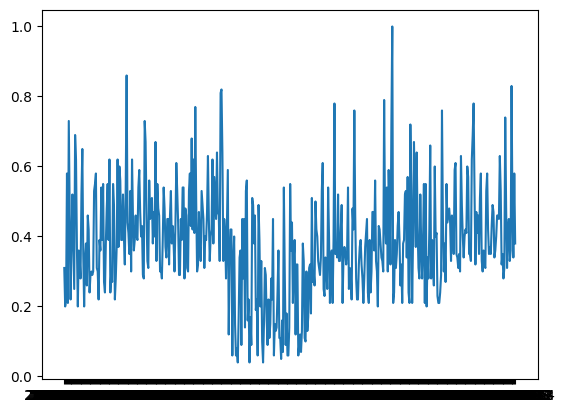

In [248]:
from matplotlib import pyplot as plt

prop_1_df = complete_dataset_df[complete_dataset_df['property_id'] == 'P0']
prop_1_df.sort_values('date')
plt.plot(prop_1_df['date'],prop_1_df['demand'])

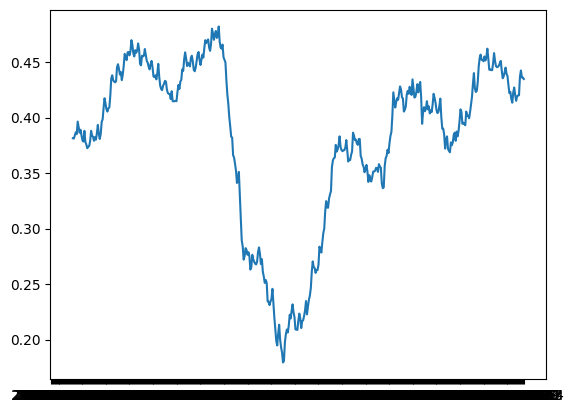

In [249]:
rolling_mean = prop_1_df['demand'].rolling(30).mean()
plt.plot(prop_1_df['date'], rolling_mean)

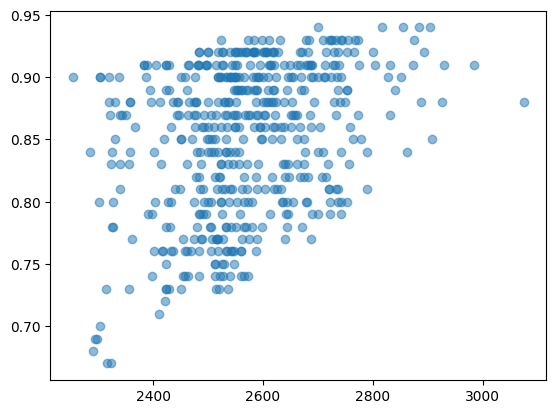

In [250]:
plt.scatter(
    prop_1_df['final_price'],
    prop_1_df['occupancy_rate'],
    alpha=0.5
)

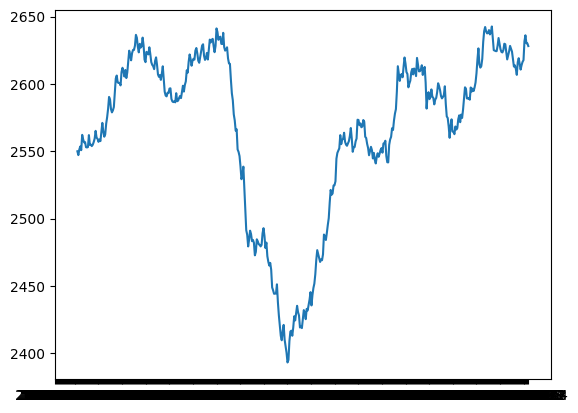

In [251]:
plt.plot(prop_1_df['date'],
         prop_1_df['final_price'].rolling(30).mean())

In [252]:
prop_1_df.corr(numeric_only=True)

,location_score,amenities_score,rating,base_price,month,weekend,holiday,demand,competitor_price,nearby_event,market_trend,final_price,occupancy_rate,revenue
location_score,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
amenities_score,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
rating,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
base_price,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
month,NaN,NaN,NaN,NaN,1.000000,0.007526,0.003452,-0.206989,-0.172411,0.024464,0.190918,-0.185318,-0.078382,-0.147947
weekend,NaN,NaN,NaN,NaN,0.007526,1.000000,0.079366,0.524543,0.463598,0.035014,0.004246,0.519762,0.168640,0.384531
holiday,NaN,NaN,NaN,NaN,0.003452,0.079366,1.000000,0.349850,0.334638,0.002866,0.062595,0.337326,0.170856,0.298443
demand,NaN,NaN,NaN,NaN,-0.206989,0.524543,0.349850,1.000000,0.887648,0.459618,0.008309,0.973259,0.352649,0.746141
competitor_price,NaN,NaN,NaN,NaN,-0.172411,0.463598,0.334638,0.887648,1.000000,0.398872,0.072802,0.911524,0.691646,0.952469
nearby_event,NaN,NaN,NaN,NaN,0.024464,0.035014,0.002866,0.459618,0.398872,1.000000,-0.033738,0.447349,0.130741,0.325272
